In [2]:
!pip install wfdb neurokit2

import numpy as np
import pandas as pd
import os
import wfdb
import neurokit2 as nk

from scipy.io import loadmat
from scipy.signal import resample

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D,
                                     BatchNormalization, Bidirectional,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.models import Model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 29.0 MB/s eta 0:00:00


2026-04-30 03:32:34.382467: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777519954.595397      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777519954.662809      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777519955.171189      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777519955.171240      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777519955.171243      57 computation_placer.cc:177] computation placer alr

In [3]:
TARGET_FS = 125
BEAT_LEN = 125 * 3 # final input length

def resample_signal(signal, orig_fs):
    target_len = int(len(signal) * TARGET_FS / orig_fs)
    return resample(signal, target_len)

def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

def detect_r_peaks(signal):
    _, rpeaks = nk.ecg_peaks(signal, sampling_rate=TARGET_FS)
    return rpeaks["ECG_R_Peaks"]

def extract_beats(signal, peaks):
    beats = []

    # compute RR intervals
    rr_intervals = np.diff(peaks)
    if len(rr_intervals) == 0:
        return beats

    rr_median = np.median(rr_intervals)

    for i, p in enumerate(peaks):
        # dynamic window based on RR interval (closer to paper idea)
        start = int(p - 0.3 * rr_median)
        end   = int(p + 0.6 * rr_median)

        if start < 0 or end > len(signal):
            continue

        beat = signal[start:end]

        # zero padding / trimming (IMPORTANT)
        if len(beat) < BEAT_LEN:
            beat = np.pad(beat, (0, BEAT_LEN - len(beat)))
        else:
            beat = beat[:BEAT_LEN]

        beats.append(beat)

    return beats

In [4]:
BASE_PATH = "/kaggle/input/datasets/awsaf49/physionet-cinc-2017-dataset/training2017"

labels_df = pd.read_csv(os.path.join(BASE_PATH, "REFERENCE-original.csv"), header=None)
labels_df.columns = ["file", "label"]

X_physio = []
y_physio = []

for i in range(len(labels_df)):
    file_id = labels_df.iloc[i]['file']
    label = labels_df.iloc[i]['label']
    
    signal = loadmat(os.path.join(BASE_PATH, file_id + ".mat"))['val'][0]
    
    # preprocess
    signal = resample_signal(signal, 300)
    signal = normalize(signal)
    
    try:
        peaks = detect_r_peaks(signal)
    except:
        continue
    
    beats = extract_beats(signal, peaks)
    
    for b in beats:
        X_physio.append(b)
        y_physio.append(label)
    
    if i % 500 == 0:
        print("Processed:", i)

X_physio = np.array(X_physio)
y_physio = np.array(y_physio)

print("Shape:", X_physio.shape)

Processed: 0
Processed: 500
Processed: 1000
Processed: 1500
Processed: 2000
Processed: 2500
Processed: 3000
Processed: 3500
Processed: 4000
Processed: 4500
Processed: 5000
Processed: 5500
Processed: 6000
Processed: 6500
Processed: 7000
Processed: 7500
Processed: 8000
Processed: 8500
Shape: (336056, 375)


In [5]:
valid_labels = ['N', 'A', 'O', '~']

X_physio_clean = []
y_physio_clean = []

for x, y in zip(X_physio, y_physio):
    if y in valid_labels:
        X_physio_clean.append(x)
        y_physio_clean.append(y)

X_physio = np.array(X_physio_clean)
y_physio = np.array(y_physio_clean)

le_physio = LabelEncoder()
y_physio = le_physio.fit_transform(y_physio)

In [6]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Reshape, Multiply, Add

def se_block(x, filters):
    se = GlobalAveragePooling1D()(x)
    se = Dense(filters // 8, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, filters))(se)
    return Multiply()([x, se])

def residual_block(x, filters):
    shortcut = x

    x = Conv1D(filters, 5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv1D(filters, 5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv1D(filters, 5, padding='same')(x)
    x = BatchNormalization()(x)

    x = se_block(x, filters)

    # match dimensions
    shortcut = Conv1D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.activations.relu(x)

    return x

In [7]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv1D(32, 5, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)

    x = Conv1D(32, 5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = MaxPooling1D(pool_size=2)(x)

    # Residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 96)
    x = residual_block(x, 128)
    x = residual_block(x, 160)

    # BiLSTM (2 layers)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.5)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [8]:
X_physio = X_physio[..., np.newaxis]

X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_physio, y_physio, test_size=0.2, random_state=42
)

In [9]:
model = build_model((BEAT_LEN, 1), 4)
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    X_train_p, y_train_p,
    validation_data=(X_val_p, y_val_p),
    epochs=10,
    batch_size=64
)

model.save("pretrained_physio.h5")

I0000 00:00:1777520049.527329      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777520049.533552      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1777520067.548119     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


4201/4201 ━━━━━━━━━━━━━━━━━━━━ 381s 86ms/step - accuracy: 0.6300 - loss: 0.8350 - val_accuracy: 0.4893 - val_loss: 1.2052
Epoch 2/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 359s 85ms/step - accuracy: 0.6854 - loss: 0.7245 - val_accuracy: 0.3405 - val_loss: 3.5627
Epoch 3/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 360s 86ms/step - accuracy: 0.7099 - loss: 0.6828 - val_accuracy: 0.3190 - val_loss: 2.1965
Epoch 4/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 361s 86ms/step - accuracy: 0.7273 - loss: 0.6492 - val_accuracy: 0.6123 - val_loss: 0.9561
Epoch 5/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 359s 86ms/step - accuracy: 0.7429 - loss: 0.6169 - val_accuracy: 0.6705 - val_loss: 0.7974
Epoch 6/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 356s 85ms/step - accuracy: 0.7611 - loss: 0.5772 - val_accuracy: 0.6982 - val_loss: 0.7783
Epoch 7/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 356s 85ms/step - accuracy: 0.7775 - loss: 0.5447 - val_accuracy: 0.7607 - val_loss: 0.5806
Epoch 8/10
4201/4201 ━━━━━━━━━━━━━━━━━━━━ 356s 85ms/step - accuracy: 0.7922 - lo

In [10]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

MIT_PATH = "/kaggle/working/mitdb"

records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

mapping = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q'
}

X_mit = []
y_mit = []

for record in records:
    rec = wfdb.rdrecord(f"{MIT_PATH}/{record}")
    ann = wfdb.rdann(f"{MIT_PATH}/{record}", 'atr')
    
    signal = rec.p_signal[:,0]
    
    signal = resample_signal(signal, 360)
    signal = normalize(signal)
    
    peaks = ann.sample
    
    for i in range(len(peaks)):
        symbol = ann.symbol[i]
        
        if symbol not in mapping:
            continue
        
        p = int(peaks[i] * TARGET_FS / 360)
        
        BEAT_LEN = 375

        start = p - 150
        end   = p + 225
        
        if start < 0 or end > len(signal):
            continue
        
        beat = signal[start:end]
        
        X_mit.append(beat)
        y_mit.append(mapping[symbol])

X_mit = np.array(X_mit)
y_mit = np.array(y_mit)

print("MIT shape:", X_mit.shape)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [11]:
le_mit = LabelEncoder()
y_mit = le_mit.fit_transform(y_mit)

X_mit = X_mit[..., np.newaxis]

X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_mit, y_mit, test_size=0.2, random_state=42
)

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_m),
    y=y_train_m
)

class_weights = dict(enumerate(class_weights))

In [13]:
base_model = tf.keras.models.load_model("pretrained_physio.h5")

# remove last layer properly
x = base_model.layers[-2].output

outputs = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# IMPORTANT: load weights except last layer already handled by architecture reuse
for layer in model.layers:
    layer.trainable = True

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
X_train_m = X_train_m.reshape(-1, 375, 1)
X_val_m   = X_val_m.reshape(-1, 375, 1)

In [16]:
print(X_train_m.shape)

(87452, 375, 1)


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          # safer than accuracy
    patience=10,                # allow learning stabilization
    restore_best_weights=True,
    verbose=1
)

In [18]:
history = model.fit(
    X_train_m, y_train_m,
    validation_data=(X_val_m, y_val_m),
    epochs=10,
    batch_size=250,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 249ms/step - accuracy: 0.4068 - loss: 1.3700 - val_accuracy: 0.8220 - val_loss: 0.5668
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.8175 - loss: 0.5359 - val_accuracy: 0.8911 - val_loss: 0.3751
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 241ms/step - accuracy: 0.8848 - loss: 0.3506 - val_accuracy: 0.8969 - val_loss: 0.3788
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 241ms/step - accuracy: 0.9111 - loss: 0.2805 - val_accuracy: 0.7990 - val_loss: 0.6573
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.9226 - loss: 0.2216 - val_accuracy: 0.8252 - val_loss: 0.5346
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.9230 - loss: 0.2208 - val_accuracy: 0.9229 - val_loss: 0.2527
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 241ms/step - accuracy: 0.9321 - loss: 0.2251 - val_accuracy: 0.8936 - val_loss: 0.3227
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 241ms/step - accuracy: 0.9385 - loss: 

In [19]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_val_m), axis=1)

print(classification_report(y_val_m, y_pred))

684/684 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
              precision    recall  f1-score   support

           0       0.23      0.83      0.37       164
           1       0.99      0.94      0.97     18078
           2       0.98      0.97      0.98      1593
           3       0.52      0.95      0.67       564
           4       0.91      0.95      0.93      1464

    accuracy                           0.94     21863
   macro avg       0.73      0.93      0.78     21863
weighted avg       0.97      0.94      0.95     21863



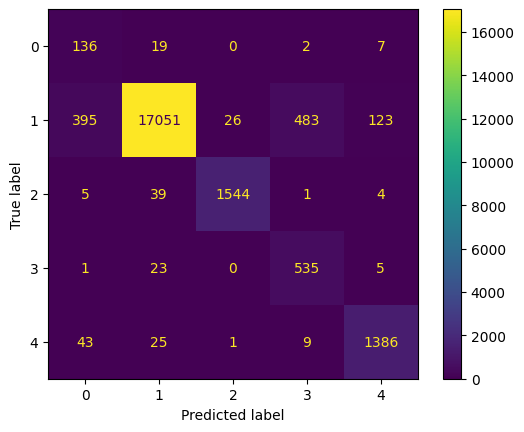

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_m, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

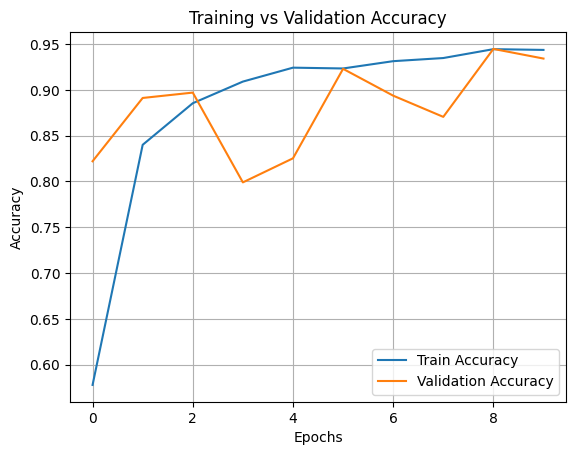

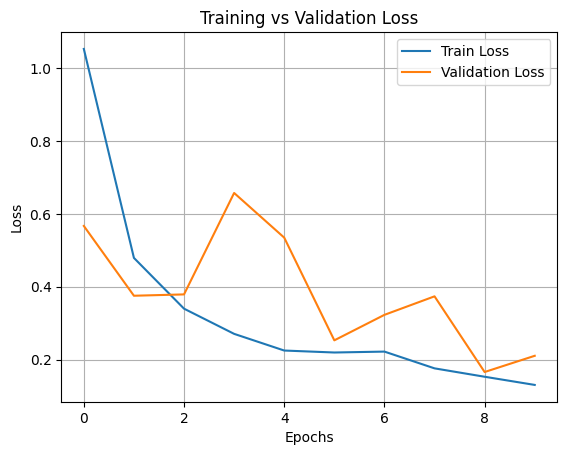

In [21]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()